<a href="https://colab.research.google.com/github/AntonySSk/Machine_Learning/blob/dev/%D0%9B%D0%912_2_%D0%9C%D0%9D_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_2_%D1%88%D0%B0%D0%B1%D0%BB%D0%BE%D0%BD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Школа, 3-9

---



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sootersaalu/amazon-top-50-bestselling-books-2009-2019")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-top-50-bestselling-books-2009-2019' dataset.
Path to dataset files: /kaggle/input/amazon-top-50-bestselling-books-2009-2019


1. Прочитайте csv файл (використовуйте функцію read_csv)

In [3]:
file_path = os.path.join(path, "bestsellers with categories.csv")
df = pd.read_csv(file_path)
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


2.	Реалізувати 2 способи завантаження файлу (з комп'ютера та кагл)

In [7]:
# Спосіб 1: З Кагл (за допомогою завантаженого шляху path через kagglehub)
df_kaggle = pd.read_csv(os.path.join(path, "bestsellers with categories.csv"))

# Спосіб 2: З комп'ютера (вибір файлу через інтерфейс Google Colab)
from google.colab import files

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df_local = pd.read_csv(file_name)

Saving bestsellers with categories.zip to bestsellers with categories (1).zip


 3.	Виведіть перших п'ять рядків (використовується функція head)

In [8]:
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


4.	Виведіть розміри датасету (використовуйте метод shape)

In [9]:
df.shape

(550, 7)

5. Наявність дублікатів за назвою, видалити дублікати

In [10]:
# Перевірка кількості дублікатів за назвою книги ('Name')
duplicates_count = df.duplicated(subset=['Name']).sum()
print(f"Кількість дублікатів за назвою: {duplicates_count}")

Кількість дублікатів за назвою: 199


In [11]:
# Видалення дублікатів за назвою (залишаємо перше входження)
df = df.drop_duplicates(subset=['Name'], keep='first')

6.	Про скільки книг зберігає дані датасет?

In [14]:
# Кількість книг після видалення дублікатів
num_books = df['Name'].nunique()
print(f"Датасет зберігає дані про {num_books} книгу.")

Датасет зберігає дані про 351 книгу.


7. перейменувати стовпці
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']

In [15]:
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']
df.head()

,name,author,user_rating,reviews,price,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


8. виведіть кількість пропусків (na) у кожному зі стовпців (використовуйте функції isna та sum)

In [16]:
df.isna().sum()

,0
name,0
author,0
user_rating,0
reviews,0
price,0
year,0
genre,0


9.	Перевірте, які унікальні значення в колонці genre (використовуйте функцію unique)
Які є унікальні жанри?

In [17]:
df['genre'].unique()

array(['Non Fiction', 'Fiction'], dtype=object)

Унікальними жанрами в датасеті є Fiction (Художня література) та Non Fiction (Документальна література).

10. подивіться розподіл цін: побудуйте діаграму (використовуйте kind='hist')

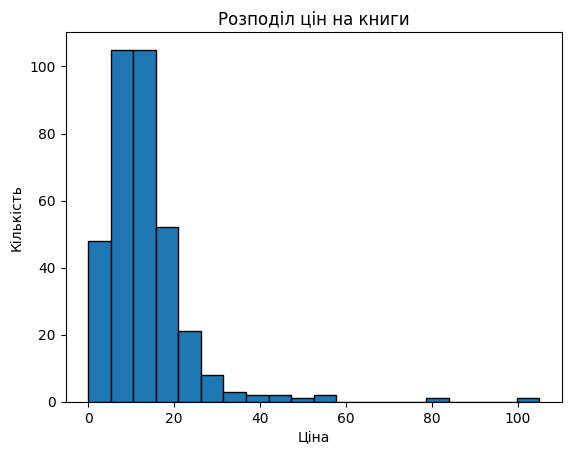

In [18]:
df['price'].plot(kind='hist', bins=20, edgecolor='black', title='Розподіл цін на книги')
plt.xlabel('Ціна')
plt.ylabel('Кількість')
plt.show()

11.	Визначте, яка ціна у нас максимальна, мінімальна, середня, медіанна (використовуйте функції max, min, mean, median)

In [19]:
print("Максимальна ціна:", df['price'].max())
print("Мінімальна ціна:", df['price'].min())
print("Середня ціна:", df['price'].mean())
print("Медіанна ціна:", df['price'].median())

Максимальна ціна: 105
Мінімальна ціна: 0
Середня ціна: 13.076923076923077
Медіанна ціна: 12.0


12.	Який рейтинг у датасеті найвищий?

In [20]:
max_rating = df['user_rating'].max()
print("Найвищий рейтинг:", max_rating)

Найвищий рейтинг: 4.9


13.	Скільки книг мають такий рейтинг?

In [21]:
count_max_rating = (df['user_rating'] == df['user_rating'].max()).sum()
print("Кількість книг з найвищим рейтингом:", count_max_rating)

Кількість книг з найвищим рейтингом: 28


14. У якої книги найбільше відгуків?

In [22]:
most_reviewed_book = df.loc[df['reviews'].idxmax(), 'name']
print("Книга з найбільшою кількістю відгуків:", most_reviewed_book)

Книга з найбільшою кількістю відгуків: Where the Crawdads Sing


15.	З тих книг, що потрапили до Топ-50 у 2015 році, яка книга найдорожча (можна використати проміжний датафрейм)?

In [23]:
df_2015 = df[df['year'] == 2015]
most_expensive_2015 = df_2015.loc[df_2015['price'].idxmax(), 'name']
print("Найдорожча книга 2015 року:", most_expensive_2015)

Найдорожча книга 2015 року: Go Set a Watchman: A Novel


16. Скільки книг жанру Fiction потрапили до Топ-50 у 2010 році (використовуйте &)?

In [24]:
fiction_2010_count = len(df[(df['genre'] == 'Fiction') & (df['year'] == 2010)])
print("Кількість книг жанру Fiction у 2010 році:", fiction_2010_count)

Кількість книг жанру Fiction у 2010 році: 17


17. Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках (використовуйте | або функцію isin)?


In [25]:
count_4_9_2010_2011 = len(df[(df['user_rating'] == 4.9) & (df['year'].isin([2010, 2011]))])
print("Кількість книг з рейтингом 4.9 у 2010 та 2011 роках:", count_4_9_2010_2011)

Кількість книг з рейтингом 4.9 у 2010 та 2011 роках: 1


18. Відсортуємо за зростанням ціни всі книги, які потрапили в рейтинг у 2015 році і коштують дешевше за 8 доларів (використовуйте функцію sort_values).
Яка книга остання у відсортованому списку?

In [26]:
# Фільтрація книг за 2015 рік із ціною < 8 доларів та сортування за зростанням ціни
sorted_books_2015 = df[(df['year'] == 2015) & (df['price'] < 8)].sort_values('price')

# Виведення відсортованого списку та останньої книги
print(sorted_books_2015[['name', 'price']])
print("\nОстання книга у відсортованому списку:", sorted_books_2015.iloc[-1]['name'])

                                                  name  price
54   Creative Haven Creative Cats Coloring Book (Ad...      4
123                               Giraffes Can't Dance      4
55   Creative Haven Owls Coloring Book (Adult Color...      5
28                        Baby Touch and Feel: Animals      5
63                      Dear Zoo: A Lift-the-Flap Book      5
89   Dover Creative Haven Art Nouveau Animal Design...      5
201  Killing Reagan: The Violent Assault That Chang...      5
16   Adult Coloring Book: Stress Relieving Animal D...      6
17      Adult Coloring Book: Stress Relieving Patterns      6
253              Old School (Diary of a Wimpy Kid #10)      7

Остання книга у відсортованому списку: Old School (Diary of a Wimpy Kid #10)


Остання книга у відсортованому списку - 'Old School (Diary of a Wimpy Kid #10)'.

19. Вивести максимальну та мінімальну ціни для кожного з жанрів (використовуйте функції groupby та agg, для підрахунку мінімальних та максимальних значень використовуйте maxта min). Не беріть усі стовпці, виберете тільки потрібні вам.

In [27]:
df.groupby('genre')['price'].agg(['max', 'min'])

,max,min
genre,,
Fiction,82,0
Non Fiction,105,0
